# Fake News Detection – Experiment Notebook

This notebook includes:
- NLP preprocessing
- Traditional ML models
- BERT-based classification
- Model comparison and evaluation

Final model selected: BERT (based on validation accuracy).

In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [10]:
TRUE_PATH = "../dataset/True.csv"
FAKE_PATH = "../dataset/Fake.csv"

In [11]:
True_df = pd.read_csv(TRUE_PATH)
Fake_df = pd.read_csv(FAKE_PATH)

In [12]:
True_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [13]:
True_df.tail()

,title,text,subject,date
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017"


In [14]:
True_df.shape

(21417, 4)

In [15]:

True_df.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [16]:
True_df.duplicated().sum()

206

In [17]:
True_df = True_df.drop_duplicates()

In [18]:
True_df.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [19]:
True_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21211 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21211 non-null  object
 1   text     21211 non-null  object
 2   subject  21211 non-null  object
 3   date     21211 non-null  object
dtypes: object(4)
memory usage: 828.6+ KB


In [20]:
Fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [21]:
Fake_df.tail()

,title,text,subject,date
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016"


In [22]:
Fake_df.shape

(23481, 4)

In [23]:
Fake_df.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [24]:
Fake_df.duplicated().sum()

3

In [25]:
Fake_df = Fake_df.drop_duplicates()

In [26]:
Fake_df.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [27]:
Fake_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23478 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23478 non-null  object
 1   text     23478 non-null  object
 2   subject  23478 non-null  object
 3   date     23478 non-null  object
dtypes: object(4)
memory usage: 917.1+ KB


In [28]:
True_df['label'] = 1
Fake_df['label'] = 0

In [29]:
df = pd.concat([True_df,Fake_df])

In [30]:
df

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


In [31]:
df = df.sample(frac=1).reset_index(drop=True)

In [32]:
df

,title,text,subject,date,label
0,Maine governor orders partial shutdown with bu...,(Reuters) - A budget impasse between Maine Gov...,politicsNews,"July 1, 2017",1
1,“TROUBLING ANSWER” To Rescue Effort During Ben...,This Benghazi timeline by Rep Roskam explains ...,politics,"Jun 29, 2016",0
2,Palestinian billionaire Masri back in Jordan a...,AMMAN (Reuters) - Palestinian billionaire Sabi...,worldnews,"December 19, 2017",1
3,Exclusive: U.S. document certifies Honduras as...,WASHINGTON (Reuters) - The U.S. State Departme...,politicsNews,"December 4, 2017",1
4,FBI INFORMANT Blows The Whistle on Obama DOJ’s...,A former FBI informant who blew the whistle on...,left-news,"Oct 27, 2017",0
...,...,...,...,...,...
44684,Secret Documents Reveal Connection Between Pl...,In the immediate aftermath of the shooting at ...,News,"April 12, 2016",0
44685,Guatemala president retains immunity from pros...,GUATEMALA CITY (Reuters) - Guatemala s Congres...,worldnews,"September 11, 2017",1
44686,Senate intel committee Democrat wants to speak...,WASHINGTON (Reuters) - The Senate intelligence...,politicsNews,"July 10, 2017",1
44687,Utah Republicans defend Romney after Bannon's ...,WASHINGTON (Reuters) - Utah Republicans on Wed...,politicsNews,"December 6, 2017",1


In [33]:
df.shape

(44689, 5)

In [34]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [35]:
df['label'].unique()

array([1, 0], dtype=int64)

In [36]:
df['label'].value_counts()

label
0    23478
1    21211
Name: count, dtype: int64

basic pre- processing done

C:\Users\juhi bandekar\AppData\Local\Temp\ipykernel_27324\2193037538.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette='pastel', edgecolor='black')


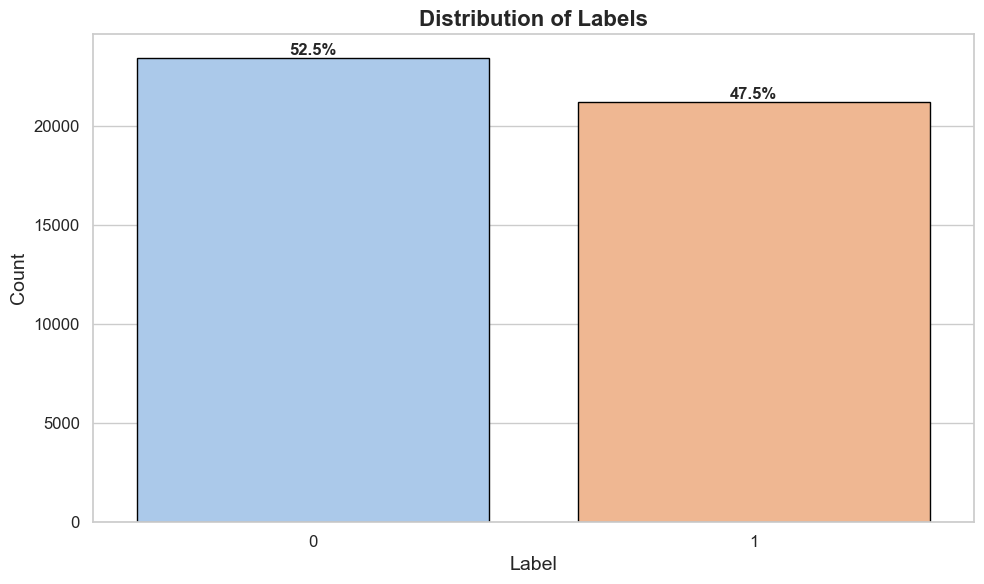

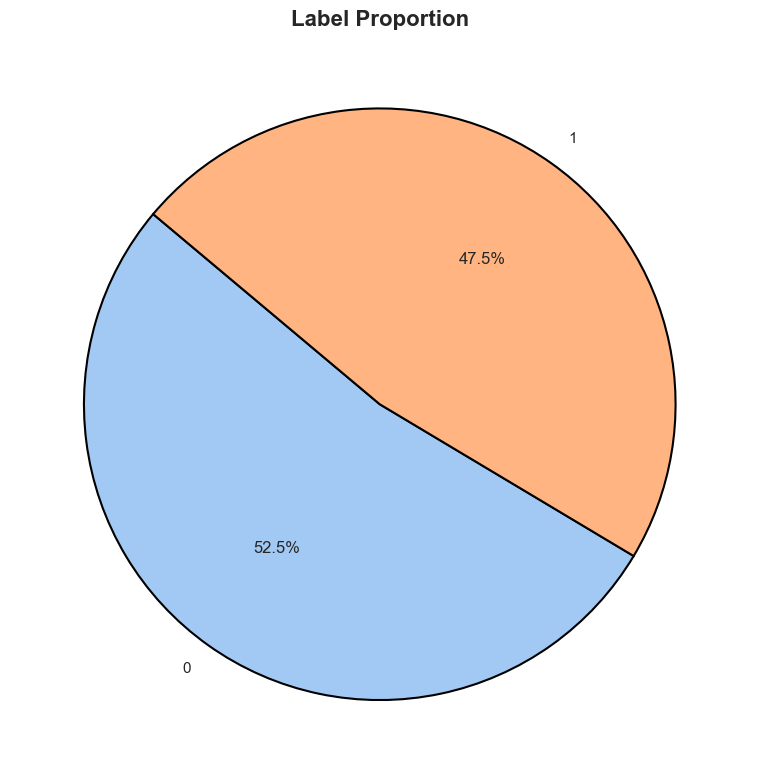

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='label', palette='pastel', edgecolor='black')

total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribution of Labels', fontsize=16, fontweight='bold')
plt.xlabel('Label', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
colors = sns.color_palette('pastel')
label_counts = df['label'].value_counts()
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=colors,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
plt.title('Label Proportion', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
df['subject'].unique()

array(['politicsNews', 'politics', 'worldnews', 'left-news', 'News',
       'Government News', 'Middle-east', 'US_News'], dtype=object)

In [39]:
df['subject'].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

C:\Users\juhi bandekar\AppData\Local\Temp\ipykernel_27324\2791861253.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='subject', palette='pastel', edgecolor='black')


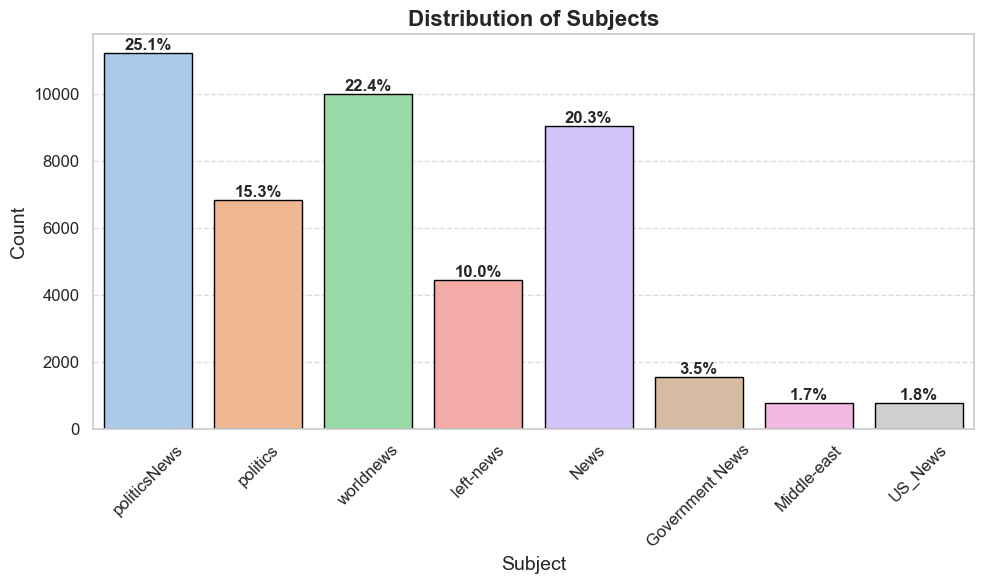

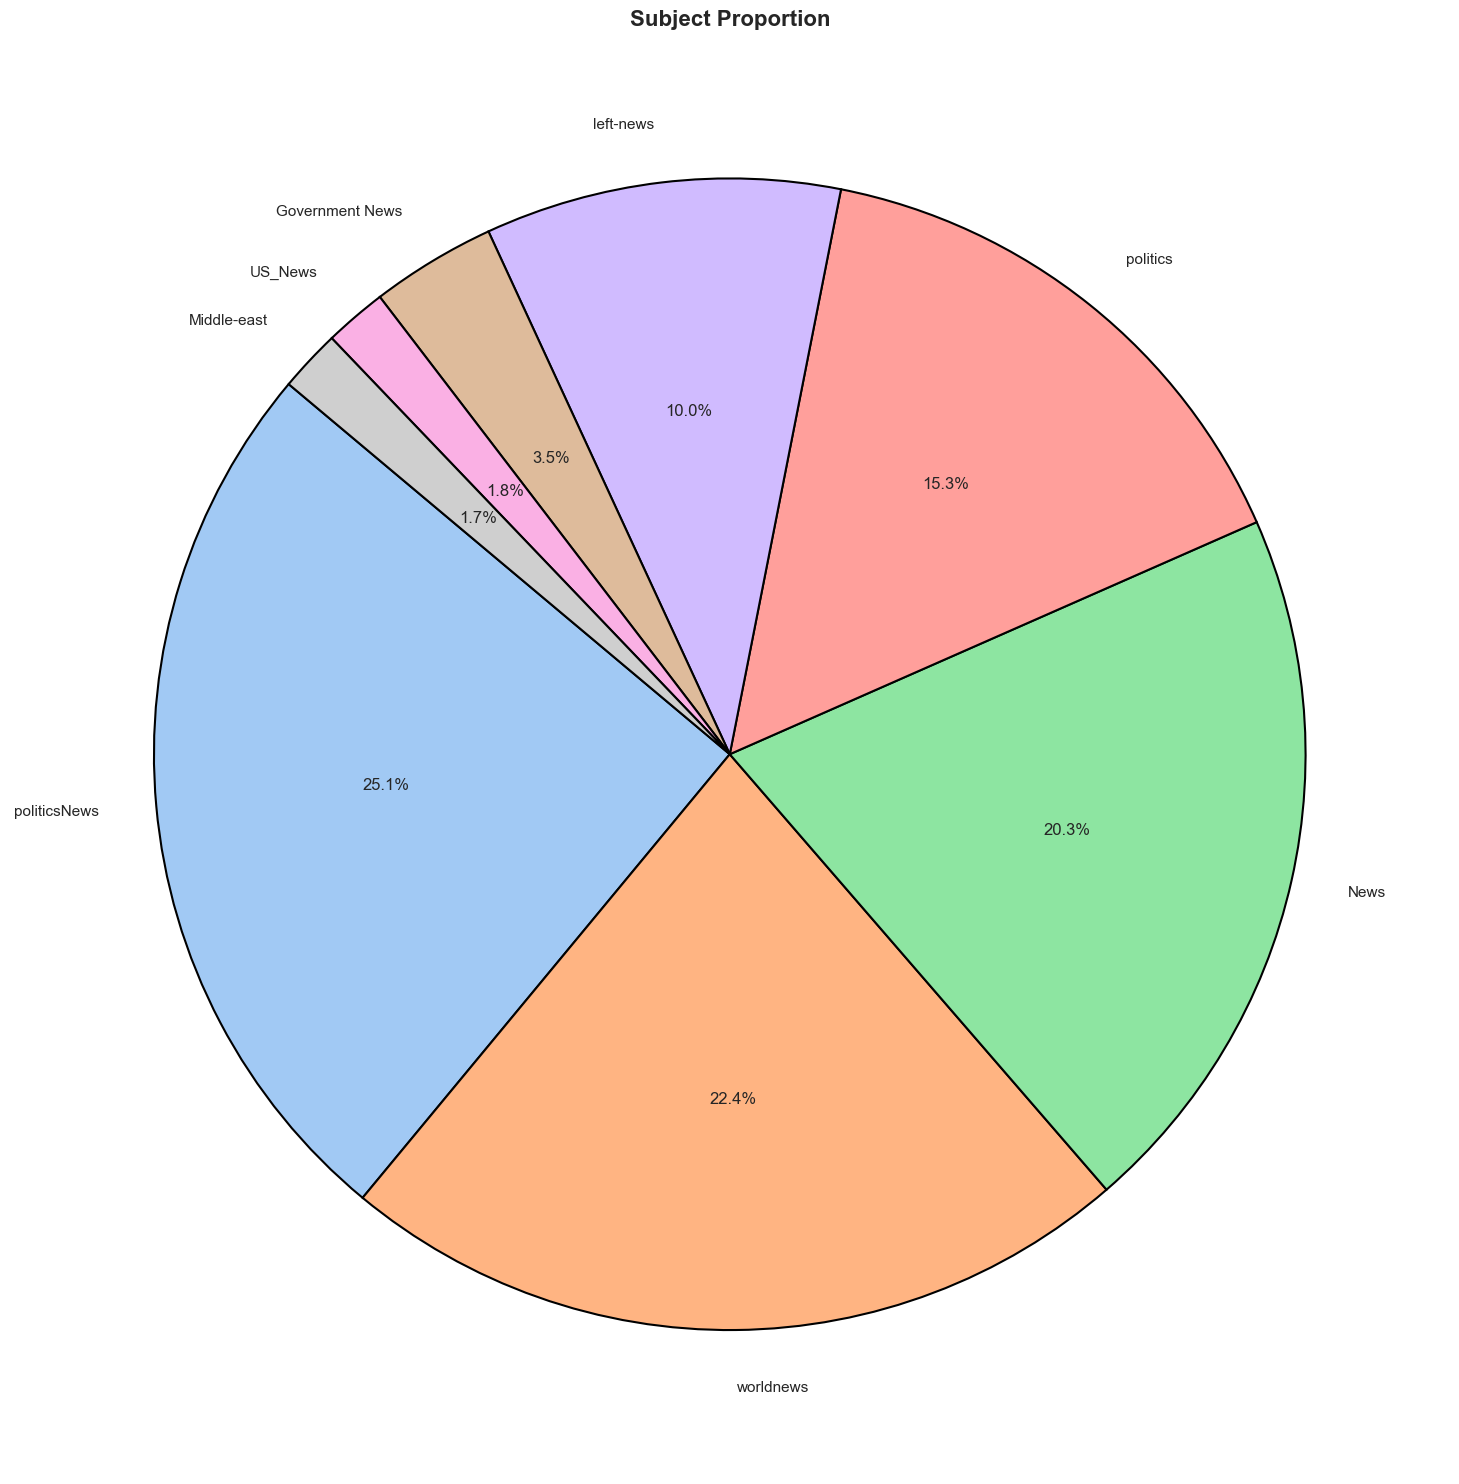

In [40]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='subject', palette='pastel', edgecolor='black')

total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribution of Subjects', fontsize=16, fontweight='bold')
plt.xlabel('Subject', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 15))
colors = sns.color_palette('pastel')
subject_counts = df['subject'].value_counts()

plt.pie(subject_counts, labels=subject_counts.index, autopct='%1.1f%%', startangle=140, colors=colors,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
plt.title('Subject Proportion', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

🔹 Data Visualization

Exploratory Data Analysis (EDA) was performed to understand:

Class distribution (Fake vs Real)

Word frequency patterns

Text length distribution

Model performance comparison

In [41]:
df['news'] = df['title'] + ' ' + df['text']

In [42]:
df

,title,text,subject,date,label,news
0,Maine governor orders partial shutdown with bu...,(Reuters) - A budget impasse between Maine Gov...,politicsNews,"July 1, 2017",1,Maine governor orders partial shutdown with bu...
1,“TROUBLING ANSWER” To Rescue Effort During Ben...,This Benghazi timeline by Rep Roskam explains ...,politics,"Jun 29, 2016",0,“TROUBLING ANSWER” To Rescue Effort During Ben...
2,Palestinian billionaire Masri back in Jordan a...,AMMAN (Reuters) - Palestinian billionaire Sabi...,worldnews,"December 19, 2017",1,Palestinian billionaire Masri back in Jordan a...
3,Exclusive: U.S. document certifies Honduras as...,WASHINGTON (Reuters) - The U.S. State Departme...,politicsNews,"December 4, 2017",1,Exclusive: U.S. document certifies Honduras as...
4,FBI INFORMANT Blows The Whistle on Obama DOJ’s...,A former FBI informant who blew the whistle on...,left-news,"Oct 27, 2017",0,FBI INFORMANT Blows The Whistle on Obama DOJ’s...
...,...,...,...,...,...,...
44684,Secret Documents Reveal Connection Between Pl...,In the immediate aftermath of the shooting at ...,News,"April 12, 2016",0,Secret Documents Reveal Connection Between Pl...
44685,Guatemala president retains immunity from pros...,GUATEMALA CITY (Reuters) - Guatemala s Congres...,worldnews,"September 11, 2017",1,Guatemala president retains immunity from pros...
44686,Senate intel committee Democrat wants to speak...,WASHINGTON (Reuters) - The Senate intelligence...,politicsNews,"July 10, 2017",1,Senate intel committee Democrat wants to speak...
44687,Utah Republicans defend Romney after Bannon's ...,WASHINGTON (Reuters) - Utah Republicans on Wed...,politicsNews,"December 6, 2017",1,Utah Republicans defend Romney after Bannon's ...


In [43]:
df['news']

0        Maine governor orders partial shutdown with bu...
1        “TROUBLING ANSWER” To Rescue Effort During Ben...
2        Palestinian billionaire Masri back in Jordan a...
3        Exclusive: U.S. document certifies Honduras as...
4        FBI INFORMANT Blows The Whistle on Obama DOJ’s...
                               ...                        
44684     Secret Documents Reveal Connection Between Pl...
44685    Guatemala president retains immunity from pros...
44686    Senate intel committee Democrat wants to speak...
44687    Utah Republicans defend Romney after Bannon's ...
44688    White House threatens to veto Senate defense b...
Name: news, Length: 44689, dtype: object

In [44]:
df_new = df.copy()

In [45]:
def clean_text(text):
    text = text.lower() 
    return text.strip()

In [46]:
df_new['news'] = df_new['news'].apply(lambda x: clean_text(x))

In [47]:
df_new['news']

0        maine governor orders partial shutdown with bu...
1        “troubling answer” to rescue effort during ben...
2        palestinian billionaire masri back in jordan a...
3        exclusive: u.s. document certifies honduras as...
4        fbi informant blows the whistle on obama doj’s...
                               ...                        
44684    secret documents reveal connection between pla...
44685    guatemala president retains immunity from pros...
44686    senate intel committee democrat wants to speak...
44687    utah republicans defend romney after bannon's ...
44688    white house threatens to veto senate defense b...
Name: news, Length: 44689, dtype: object

In [48]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [49]:
def remove_punctuation(text):
    punctuationfree="".join([i for i in text if i not in string.punctuation])
    return punctuationfree

In [50]:
df_new['news']= df_new['news'].apply(lambda x:remove_punctuation(x))

In [51]:
df_new['news']

0        maine governor orders partial shutdown with bu...
1        “troubling answer” to rescue effort during ben...
2        palestinian billionaire masri back in jordan a...
3        exclusive us document certifies honduras as su...
4        fbi informant blows the whistle on obama doj’s...
                               ...                        
44684    secret documents reveal connection between pla...
44685    guatemala president retains immunity from pros...
44686    senate intel committee democrat wants to speak...
44687    utah republicans defend romney after bannons m...
44688    white house threatens to veto senate defense b...
Name: news, Length: 44689, dtype: object

In [52]:
def remove_punctuation(text):
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

In [53]:
df_new['news']= df_new['news'].apply(lambda x:remove_punctuation(x))

In [54]:
df_new['news']

0        maine governor orders partial shutdown with bu...
1        “troubling answer” to rescue effort during ben...
2        palestinian billionaire masri back in jordan a...
3        exclusive us document certifies honduras as su...
4        fbi informant blows the whistle on obama doj’s...
                               ...                        
44684    secret documents reveal connection between pla...
44685    guatemala president retains immunity from pros...
44686    senate intel committee democrat wants to speak...
44687    utah republicans defend romney after bannons m...
44688    white house threatens to veto senate defense b...
Name: news, Length: 44689, dtype: object

In [55]:
import re

def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

In [56]:
df_new['news']= df_new['news'].apply(lambda x:remove_punctuation(x))

In [57]:
df_new['news']

0        maine governor orders partial shutdown with bu...
1        troubling answer to rescue effort during bengh...
2        palestinian billionaire masri back in jordan a...
3        exclusive us document certifies honduras as su...
4        fbi informant blows the whistle on obama dojs ...
                               ...                        
44684    secret documents reveal connection between pla...
44685    guatemala president retains immunity from pros...
44686    senate intel committee democrat wants to speak...
44687    utah republicans defend romney after bannons m...
44688    white house threatens to veto senate defense b...
Name: news, Length: 44689, dtype: object

In [58]:
import nltk
from wordcloud import WordCloud

In [59]:
stopwords = nltk.corpus.stopwords.words('english')

In [60]:
def remove_stopwords(text):
    output = " ".join(i for i in text.split() if i not in stopwords)
    return output

df_new['news'] = df_new['news'].apply(lambda x: remove_stopwords(x))

In [61]:
df_new['news']

0        maine governor orders partial shutdown budget ...
1        troubling answer rescue effort benghazi attack...
2        palestinian billionaire masri back jordan rele...
3        exclusive us document certifies honduras suppo...
4        fbi informant blows whistle obama dojs intimid...
                               ...                        
44684    secret documents reveal connection planned par...
44685    guatemala president retains immunity prosecuti...
44686    senate intel committee democrat wants speak tr...
44687    utah republicans defend romney bannons mormon ...
44688    white house threatens veto senate defense bill...
Name: news, Length: 44689, dtype: object

In [62]:
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_sentence(sentence):
    if isinstance(sentence, str):
        words = word_tokenize(sentence)
        stemmed_words = [stemmer.stem(word) for word in words]
        return ' '.join(stemmed_words)
    return sentence

df_new['news'] = df_new['news'].apply(lambda x: stem_sentence(x))

In [63]:
df_new['news']

0        main governor order partial shutdown budget li...
1        troubl answer rescu effort benghazi attack exp...
2        palestinian billionair masri back jordan relea...
3        exclus us document certifi hondura support rig...
4        fbi inform blow whistl obama doj intimid tacti...
                               ...                        
44684    secret document reveal connect plan parenthood...
44685    guatemala presid retain immun prosecut graft p...
44686    senat intel committe democrat want speak trump...
44687    utah republican defend romney bannon mormon ja...
44688    white hous threaten veto senat defens bill was...
Name: news, Length: 44689, dtype: object

In [64]:
def clean_text(text):
    text = re.sub('\[.*\]','', text).strip() 
    text = re.sub('\S*\d\S*\s*','', text).strip()  
    return text.strip()

In [65]:
df_new['news'] = df_new['news'].apply(lambda x: clean_text(x))

In [66]:
df_new['news']

0        main governor order partial shutdown budget li...
1        troubl answer rescu effort benghazi attack exp...
2        palestinian billionair masri back jordan relea...
3        exclus us document certifi hondura support rig...
4        fbi inform blow whistl obama doj intimid tacti...
                               ...                        
44684    secret document reveal connect plan parenthood...
44685    guatemala presid retain immun prosecut graft p...
44686    senat intel committe democrat want speak trump...
44687    utah republican defend romney bannon mormon ja...
44688    white hous threaten veto senat defens bill was...
Name: news, Length: 44689, dtype: object

In [67]:
def remove_urls(vTEXT):
    vTEXT = re.sub(r'(https|http)?:\/\/(\w|\.|\/|\?|\=|\&|\%)*\b', '', vTEXT, flags=re.MULTILINE)
    return(vTEXT)

In [68]:
df_new['news'] = df_new['news'].apply(lambda x: remove_urls(x))

In [69]:
df_new['news']

0        main governor order partial shutdown budget li...
1        troubl answer rescu effort benghazi attack exp...
2        palestinian billionair masri back jordan relea...
3        exclus us document certifi hondura support rig...
4        fbi inform blow whistl obama doj intimid tacti...
                               ...                        
44684    secret document reveal connect plan parenthood...
44685    guatemala presid retain immun prosecut graft p...
44686    senat intel committe democrat want speak trump...
44687    utah republican defend romney bannon mormon ja...
44688    white hous threaten veto senat defens bill was...
Name: news, Length: 44689, dtype: object

In [70]:
def remove_digits(text):
    clean_text = re.sub(r"\b[0-9]+\b\s*", "", text)
    return(text)

In [71]:
df_new['news'] = df_new['news'].apply(lambda x: remove_digits(x))

In [72]:
df_new['news']

0        main governor order partial shutdown budget li...
1        troubl answer rescu effort benghazi attack exp...
2        palestinian billionair masri back jordan relea...
3        exclus us document certifi hondura support rig...
4        fbi inform blow whistl obama doj intimid tacti...
                               ...                        
44684    secret document reveal connect plan parenthood...
44685    guatemala presid retain immun prosecut graft p...
44686    senat intel committe democrat want speak trump...
44687    utah republican defend romney bannon mormon ja...
44688    white hous threaten veto senat defens bill was...
Name: news, Length: 44689, dtype: object

In [73]:
def remove_emojis(data):
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F" 
                               u"\U0001F300-\U0001F5FF" 
                               u"\U0001F680-\U0001F6FF" 
                               u"\U0001F1E0-\U0001F1FF"  
                               "]+", flags=re.UNICODE)
    return re.sub(emoji_pattern, '', data)

In [74]:
df_new['news'] = df_new['news'].apply(lambda x: remove_emojis(x))

In [75]:
df_new['news']

0        main governor order partial shutdown budget li...
1        troubl answer rescu effort benghazi attack exp...
2        palestinian billionair masri back jordan relea...
3        exclus us document certifi hondura support rig...
4        fbi inform blow whistl obama doj intimid tacti...
                               ...                        
44684    secret document reveal connect plan parenthood...
44685    guatemala presid retain immun prosecut graft p...
44686    senat intel committe democrat want speak trump...
44687    utah republican defend romney bannon mormon ja...
44688    white hous threaten veto senat defens bill was...
Name: news, Length: 44689, dtype: object

In [76]:
df_new['news'] = df_new['news'].apply(lambda x:re.sub(r'\s+[a-zA-Z]\s+', '', x))

In [77]:
df_new['news'] = df_new['news'].apply(lambda x:re.sub(r'\s+', ' ', x, flags=re.I))

In [78]:
df_new

,title,text,subject,date,label,news
0,Maine governor orders partial shutdown with bu...,(Reuters) - A budget impasse between Maine Gov...,politicsNews,"July 1, 2017",1,main governor order partial shutdown budget li...
1,“TROUBLING ANSWER” To Rescue Effort During Ben...,This Benghazi timeline by Rep Roskam explains ...,politics,"Jun 29, 2016",0,troubl answer rescu effort benghazi attack exp...
2,Palestinian billionaire Masri back in Jordan a...,AMMAN (Reuters) - Palestinian billionaire Sabi...,worldnews,"December 19, 2017",1,palestinian billionair masri back jordan relea...
3,Exclusive: U.S. document certifies Honduras as...,WASHINGTON (Reuters) - The U.S. State Departme...,politicsNews,"December 4, 2017",1,exclus us document certifi hondura support rig...
4,FBI INFORMANT Blows The Whistle on Obama DOJ’s...,A former FBI informant who blew the whistle on...,left-news,"Oct 27, 2017",0,fbi inform blow whistl obama doj intimid tacti...
...,...,...,...,...,...,...
44684,Secret Documents Reveal Connection Between Pl...,In the immediate aftermath of the shooting at ...,News,"April 12, 2016",0,secret document reveal connect plan parenthood...
44685,Guatemala president retains immunity from pros...,GUATEMALA CITY (Reuters) - Guatemala s Congres...,worldnews,"September 11, 2017",1,guatemala presid retain immun prosecut graft p...
44686,Senate intel committee Democrat wants to speak...,WASHINGTON (Reuters) - The Senate intelligence...,politicsNews,"July 10, 2017",1,senat intel committe democrat want speak trump...
44687,Utah Republicans defend Romney after Bannon's ...,WASHINGTON (Reuters) - Utah Republicans on Wed...,politicsNews,"December 6, 2017",1,utah republican defend romney bannon mormon ja...


In [79]:
df_new = df_new[['news', 'label']]
df_new

,news,label
0,main governor order partial shutdown budget li...,1
1,troubl answer rescu effort benghazi attack exp...,0
2,palestinian billionair masri back jordan relea...,1
3,exclus us document certifi hondura support rig...,1
4,fbi inform blow whistl obama doj intimid tacti...,0
...,...,...
44684,secret document reveal connect plan parenthood...,0
44685,guatemala presid retain immun prosecut graft p...,1
44686,senat intel committe democrat want speak trump...,1
44687,utah republican defend romney bannon mormon ja...,1


In [80]:
df_new

,news,label
0,main governor order partial shutdown budget li...,1
1,troubl answer rescu effort benghazi attack exp...,0
2,palestinian billionair masri back jordan relea...,1
3,exclus us document certifi hondura support rig...,1
4,fbi inform blow whistl obama doj intimid tacti...,0
...,...,...
44684,secret document reveal connect plan parenthood...,0
44685,guatemala presid retain immun prosecut graft p...,1
44686,senat intel committe democrat want speak trump...,1
44687,utah republican defend romney bannon mormon ja...,1


✅ Preprocessing Steps:

Text Cleaning

Converted text to lowercase

Removed special characters, punctuation, and extra spaces

Eliminated irrelevant symbols

Tokenization

Split text into individual words (tokens)

Helped convert raw text into structured format

Stemming

Reduced words to their root form

Example: running → run, studies → studi

Helped reduce vocabulary size

Label Encoding

Converted categorical labels (Fake / Real) into numeric format (0 / 1)

Required for machine learning models

TFBertForSequenceClassification used for training 

🔹 Deep Learning Model – BERT

For advanced contextual understanding, the transformer-based model
TFBertForSequenceClassification was used.


In [81]:
import tensorflow as tf

In [82]:
from transformers import TFBertForSequenceClassification

In [83]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
from transformers import BertTokenizer

In [84]:

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [85]:
df_new['label'] = df_new['label'].astype('category').cat.codes
num_classes = len(df_new['label'].unique())
print(df_new['label'].value_counts())

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_new['news'], df_new['label'], 
    test_size=0.4, random_state=42
)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


C:\Users\juhi bandekar\AppData\Local\Temp\ipykernel_27324\337924647.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['label'] = df_new['label'].astype('category').cat.codes


label
0    23478
1    21211
Name: count, dtype: int64


In [86]:
import os

def tokenize(texts, max_length=128):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors="tf"
    )

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)


def create_dataset(encodings, labels):
    return tf.data.Dataset.from_tensor_slices((
        {
            'input_ids': encodings['input_ids'],
            'attention_mask': encodings['attention_mask']
        },
        labels
    ))

train_dataset = create_dataset(train_encodings, train_labels)
val_dataset = create_dataset(val_encodings, val_labels)

batch_size = 16
train_dataset = train_dataset.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_classes
)

optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

# ── Checkpoint Setup ─────────────────────────────────────
os.makedirs('./checkpoints', exist_ok=True)

callbacks = [
    # Saves full model after every epoch
    tf.keras.callbacks.ModelCheckpoint(
        filepath='./checkpoints/epoch_{epoch}',
        save_weights_only=False,
        save_best_only=False,
        verbose=1
    ),
    # Stops early if val_loss doesn't improve for 1 epoch
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=1,
        restore_best_weights=True,
        verbose=1
    ),
    # Saves all accuracy/loss logs to a CSV file
    tf.keras.callbacks.CSVLogger(
        './checkpoints/training_log.csv'
    )
]
# ─────────────────────────────────────────────────────────

epochs = 3
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    initial_epoch=2,  # ← only change to model.fit()
    callbacks=callbacks  # ← only change to model.fit()
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 3/3


1676/1676 [==============================] - ETA: 0s - loss: 0.0346 - accuracy: 0.9884
Epoch 3: saving model to ./checkpoints\epoch_3
INFO:tensorflow:Assets written to: ./checkpoints\epoch_3\assets


INFO:tensorflow:Assets written to: ./checkpoints\epoch_3\assets


1676/1676 [==============================] - 8346s 5s/step - loss: 0.0346 - accuracy: 0.9884 - val_loss: 0.0121 - val_accuracy: 0.9977


In [87]:
from sklearn.metrics import classification_report
import numpy as np

preds = model.predict(val_dataset)
y_pred = np.argmax(preds.logits, axis=1)

print(classification_report(val_labels[:len(y_pred)], y_pred))

1118/1118 [==============================] - 1493s 1s/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9300
           1       1.00      1.00      1.00      8576

    accuracy                           1.00     17876
   macro avg       1.00      1.00      1.00     17876
weighted avg       1.00      1.00      1.00     17876



In [89]:
def predict(text):
    inputs = tokenizer(
        text,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="tf"
    )
    outputs = model(inputs)
    probs = tf.nn.softmax(outputs.logits, axis=-1)
    return tf.argmax(probs, axis=1).numpy()[0]

sample_text = "The prime minister of india is narendra modi ."
print(f"Predicted class: {predict(sample_text)}")

Predicted class: 1


In [120]:
print("🔗 https://huggingface.co/avivaaaaa123/Fake-news-detector")

🔗 https://huggingface.co/avivaaaaa123/Fake-news-detector


In [94]:
from sklearn.metrics import confusion_matrix, classification_report



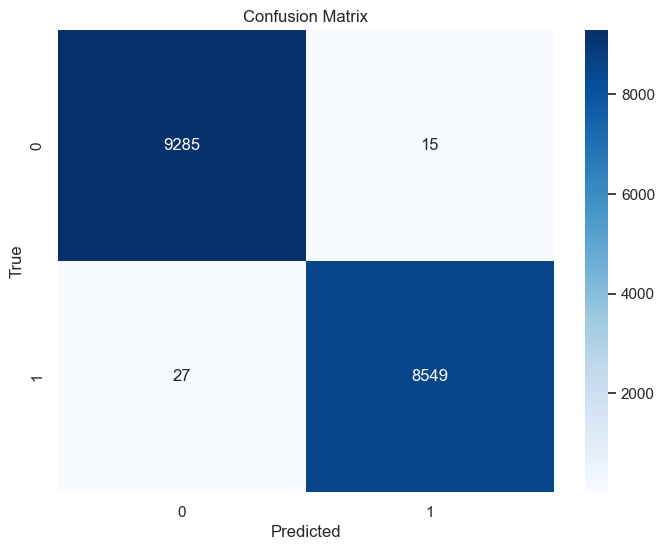

In [95]:
label_classes = df_new['label'].astype('category').cat.categories.tolist()

cm = confusion_matrix(val_labels, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_classes, yticklabels=label_classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [84]:
label_classes = [str(cls) for cls in df_new['label'].astype('category').cat.categories]

print("Classification Report:")
print(classification_report(val_labels, y_pred, target_names=label_classes))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4688
           1       1.00      1.00      1.00      4250

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [97]:
df_new.to_csv('cleaned_fake_news_data.csv')

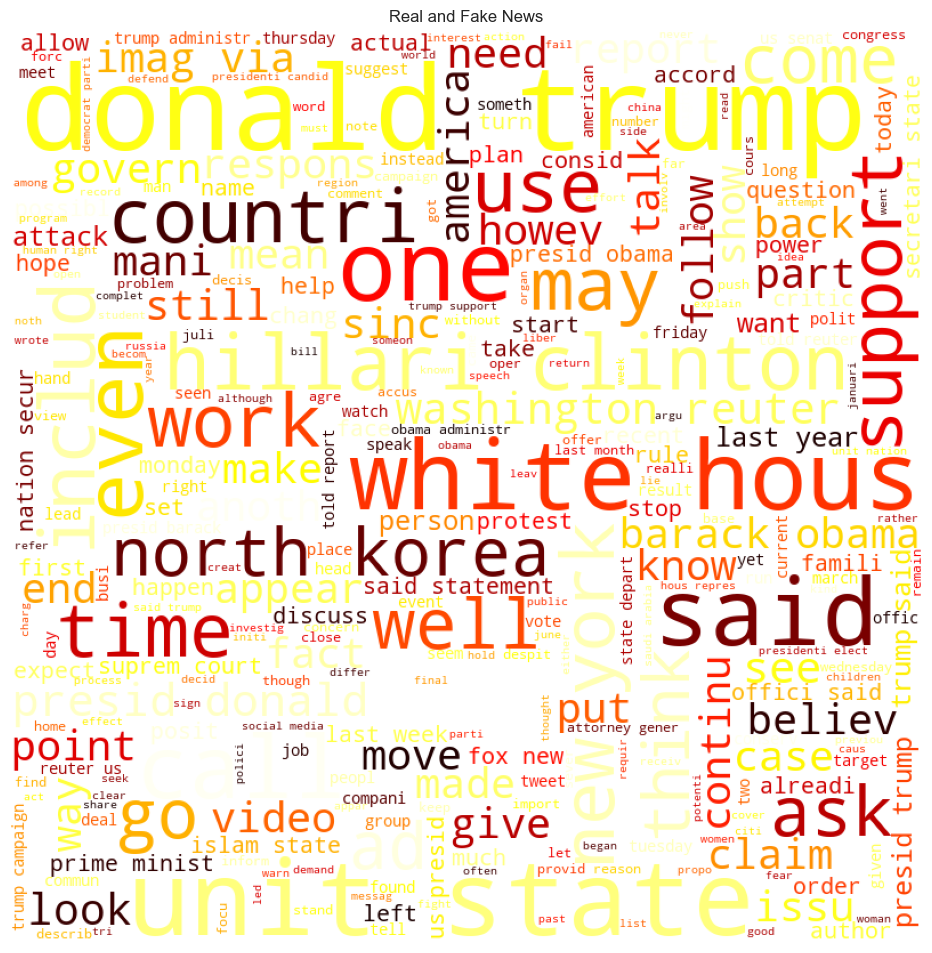

In [98]:
combined_title = ' '.join(df_new['news'])

wordcloud_img = WordCloud(width = 800, height = 800, max_words = 5000,
                            background_color ='white', colormap = 'hot_r',
                            min_font_size = 10).generate(combined_title)

plt.figure(figsize=(10,10))
plt.imshow(wordcloud_img)
plt.axis('off')
plt.title('Real and Fake News')
plt.tight_layout(pad=2)
plt.show()

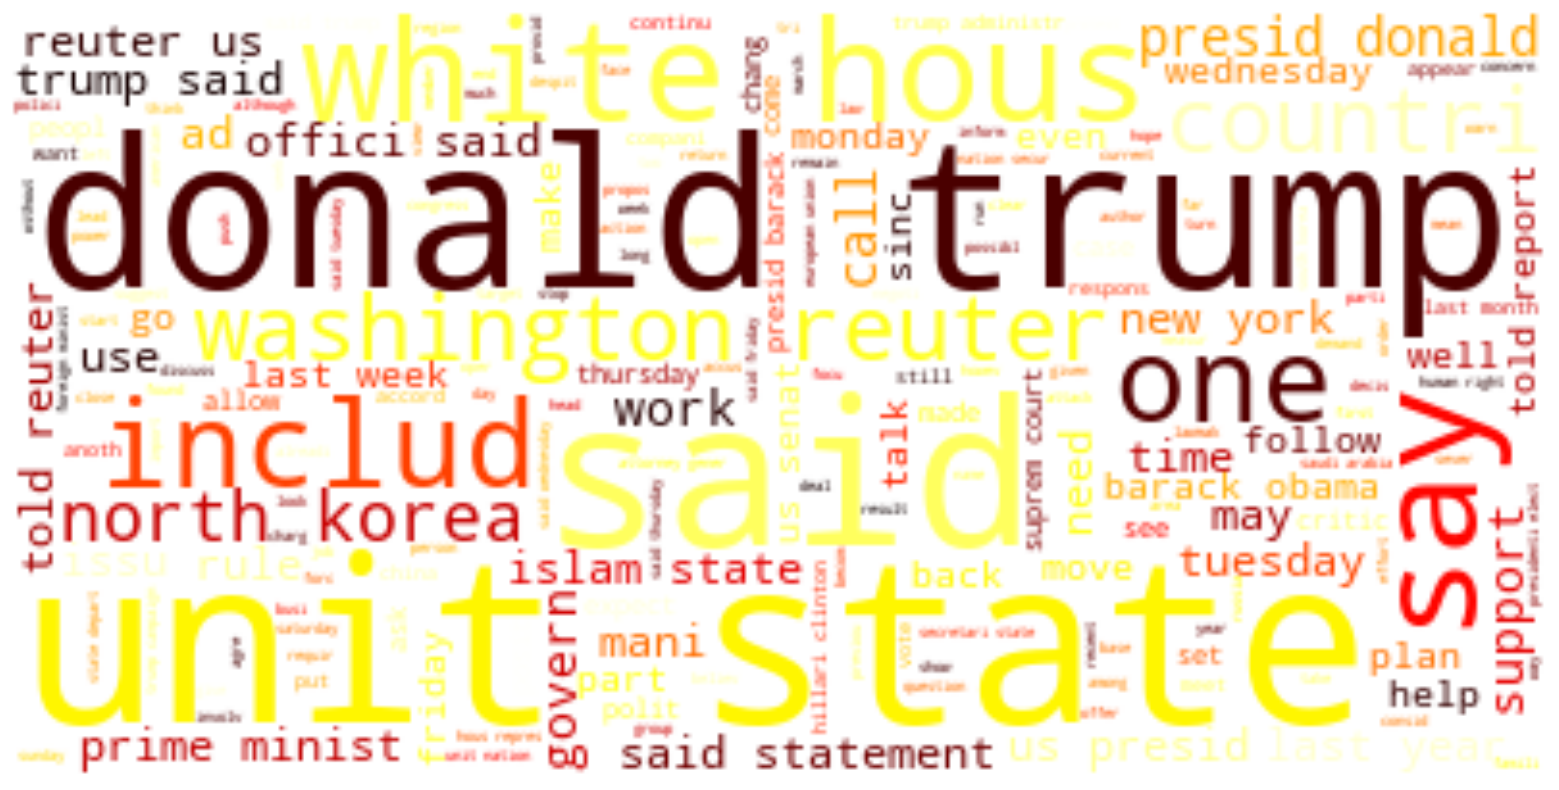

In [99]:
real_text_data = ' '.join(df_new[df_new['label'] == 1]['news'])  

if real_text_data:
    wordcloud = WordCloud(background_color='white', max_words = 5000, colormap = 'hot_r').generate(real_text_data)

    fig, ax = plt.subplots(figsize=(30, 10))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    plt.show()
else:
    print('No real text data to generate a word cloud.')

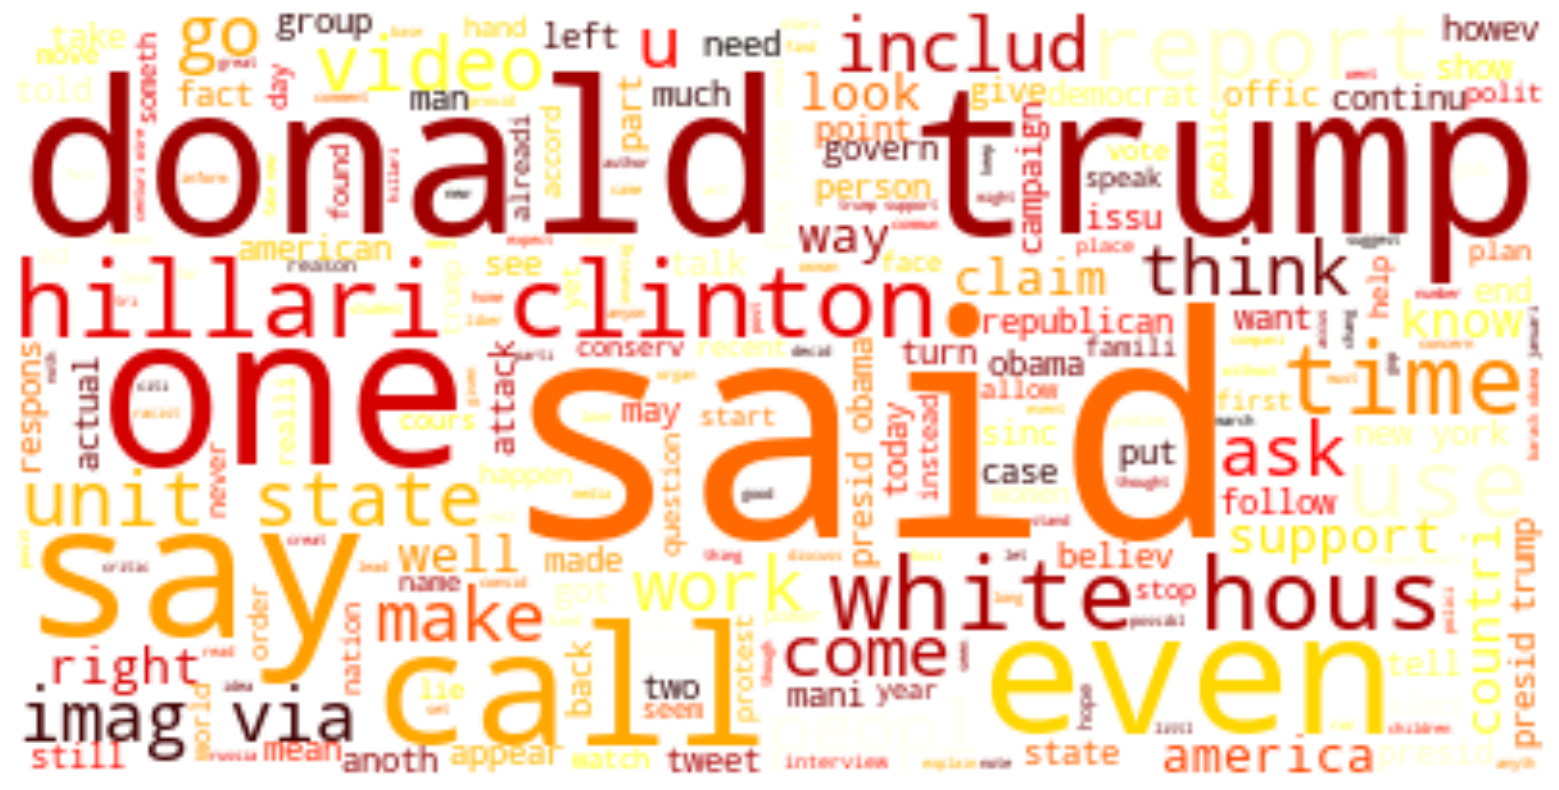

In [100]:
fake_text_data = ' '.join(df_new[df_new['label'] == 0]['news'])  

if real_text_data:
    wordcloud = WordCloud(background_color='white', max_words = 5000, colormap = 'hot_r').generate(fake_text_data)

    fig, ax = plt.subplots(figsize=(30, 10))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    plt.show()
else:
    print('No fake text data to generate a word cloud.')

In [101]:
import os

os.makedirs('./model', exist_ok=True)

# Save model
model.save_pretrained('./model/bert_model')
tokenizer.save_pretrained('./model/bert_model')

print("✅ Model saved!")

✅ Model saved!


In [ ]:
# from huggingface_hub import HfApi, login

# login(token="hf_XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")")

# api = HfApi()

# # Create repo first
# api.create_repo(
#     repo_id="avivaaaaa123/Fake-news-detector",
#     exist_ok=True
# )

# # Upload entire folder directly
# api.upload_folder(
#     folder_path="C:\\Users\\juhi bandekar\\Desktop\\fake_news_detection\\experiments\\model\\bert_model",
#     repo_id="avivaaaaa123/Fake-news-detector",
#     repo_type="model"
# )

# print("✅ Uploaded successfully!")


Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to C:\Users\juhi bandekar\.cache\huggingface\token
Login successful


tf_model.h5: 100%|██████████| 438M/438M [03:14<00:00, 2.26MB/s]   


✅ Uploaded successfully!


After completing the BERT model, traditional machine learning models were implemented for comparison.

Traditional Approach Included:

TF-IDF Vectorization

Logistic Regression

Other classical classifiers (if applied)

Unlike BERT, these models rely on statistical word frequency features rather than deep contextual embeddings... rest part is just for understanding 

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import precision_recall_fscore_support
from sklearn.feature_extraction.text import TfidfVectorizer

In [82]:
X = df_new['news']  
y = df_new['label']

In [83]:
tfidf_vectorizer = TfidfVectorizer(max_features = 10000)
X_tfidf = tfidf_vectorizer.fit_transform(X)

In [84]:
X_tfidf 

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6351490 stored elements and shape (44689, 10000)>

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, stratify = y, 
                                                    random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr_classifier = LogisticRegression(random_state = 42)
lr_classifier.fit(X_train, y_train)

In [ ]:
y_pred = lr_classifier.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", lr_accuracy)

In [ ]:
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

In [ ]:
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Label 0', 'Label 1'], 
            yticklabels=['Label 0', 'Label 1'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.tight_layout()
plt.show()

decisionTreeClassifier

In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
dt_classifier = DecisionTreeClassifier(random_state = 42)
dt_classifier.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [ ]:
y_pred = dt_classifier.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", dt_accuracy)

In [ ]:
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

In [ ]:
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Label 0', 'Label 1'], 
            yticklabels=['Label 0', 'Label 1'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(X_train, y_train)

In [ ]:
y_pred = svm_classifier.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", svm_accuracy)

In [ ]:
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

In [ ]:
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Label 0', 'Label 1'], 
            yticklabels=['Label 0', 'Label 1'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Support Vector Classifier')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
naive_bayes_classifier = MultinomialNB()
naive_bayes_classifier.fit(X_train, y_train)

In [ ]:
y_pred = naive_bayes_classifier.predict(X_test)

In [ ]:
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

In [ ]:
nb_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", nb_accuracy)

report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Label 0', 'Label 1'], 
            yticklabels=['Label 0', 'Label 1'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Naive Bayes Classifier')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_classifier = RandomForestClassifier(n_estimators=10, random_state=42)
rf_classifier.fit(X_train, y_train)

In [ ]:
y_pred = rf_classifier.predict(X_test)

In [ ]:
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", rf_accuracy)

report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Label 0', 'Label 1'], 
            yticklabels=['Label 0', 'Label 1'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.tight_layout()
plt.show()

In [ ]:
accuracies = {
    'Logistic Regression': lr_accuracy,
    'Decision Tree': dt_accuracy,
    'Support Vector Machine': svm_accuracy,
    'Multinomail Naive Bayes': nb_accuracy,
    'Random Forest': rf_accuracy
}

In [ ]:
fig = go.Figure(
    data=[
        go.Bar(x=list(accuracies.keys()), y=list(accuracies.values()))
    ],
    layout={
        'title': 'Model Comparison: Accuracy',
        'xaxis': {'title': 'Models'},
        'yaxis': {'title': 'Accuracy'}
    }
)

for model, accuracy in accuracies.items():
    fig.add_annotation(
        x=model, 
        y=accuracy,  
        text=f'{accuracy:.2f}', 
        showarrow=False, 
        font=dict(size=10),  
        xanchor='center',  
        yanchor='bottom',  
        yshift=-10  
    )

fig.show()

In [77]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

In [78]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df_new['news'])
sequences = tokenizer.texts_to_sequences(df_new['news'])
padded_sequences = pad_sequences(sequences, maxlen=100, padding='post', truncating='post')

In [79]:
labels = np.array(df_new['label'])

In [86]:
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, stratify = labels, random_state=42)

In [87]:
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [88]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [89]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10


894/894 [==============================] - 22s 22ms/step - loss: 0.0313 - accuracy: 0.9888 - val_loss: 0.0034 - val_accuracy: 0.9992
Epoch 2/10
894/894 [==============================] - 21s 23ms/step - loss: 9.1153e-04 - accuracy: 0.9998 - val_loss: 0.0059 - val_accuracy: 0.9983
Epoch 3/10
894/894 [==============================] - 21s 23ms/step - loss: 6.7846e-04 - accuracy: 0.9998 - val_loss: 0.0048 - val_accuracy: 0.9987
Epoch 4/10
894/894 [==============================] - 21s 24ms/step - loss: 7.9329e-06 - accuracy: 1.0000 - val_loss: 0.0057 - val_accuracy: 0.9987
Epoch 5/10
894/894 [==============================] - 19s 21ms/step - loss: 1.5448e-06 - accuracy: 1.0000 - val_loss: 0.0062 - val_accuracy: 0.9986
Epoch 6/10
894/894 [==============================] - 19s 21ms/step - loss: 5.4725e-07 - accuracy: 1.0000 - val_loss: 0.0061 - val_accuracy: 0.9986
Epoch 7/10
894/894 [==============================] - 17s 19ms/step - loss: 3.3711e-07 - accuracy: 1.0000 - val_lo

In [90]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

280/280 [==============================] - 1s 4ms/step


In [91]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 99.81%


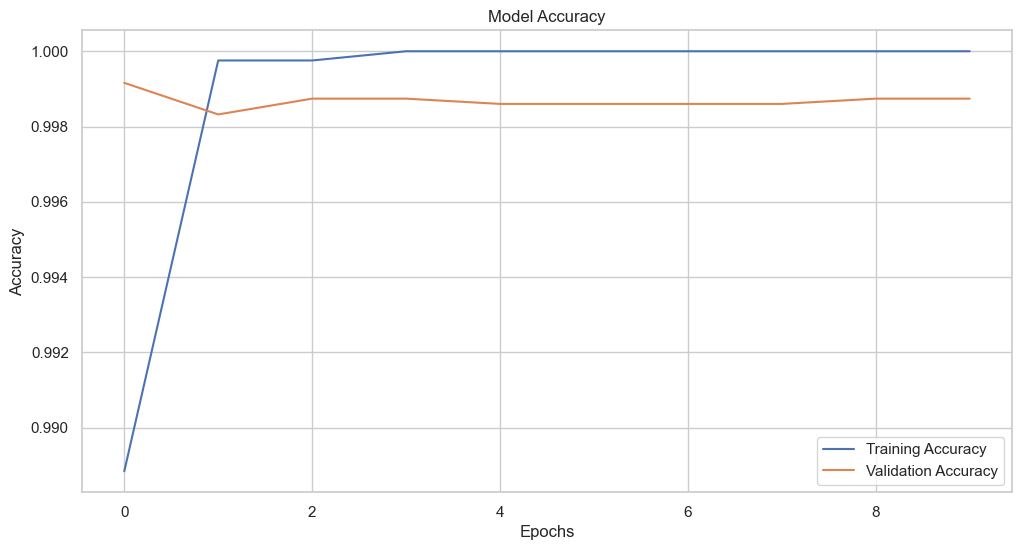

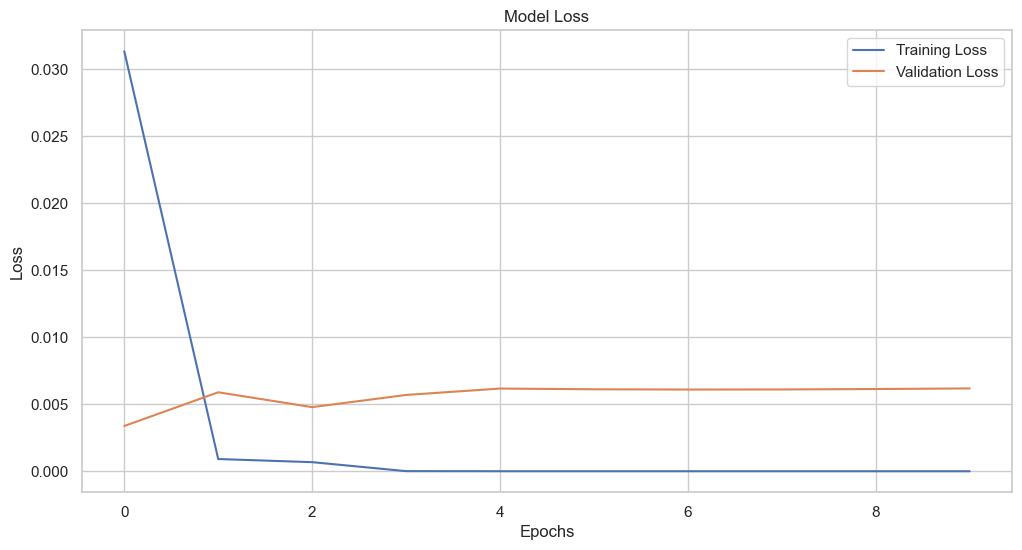

In [92]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [93]:
import pickle
import os

os.makedirs('./model', exist_ok=True)

# Save Keras model
model.save('./model/fake_news_dl_model.h5')

# Save tokenizer
with open('./model/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("✅ Both files saved in ./model folder!")


c:\Users\juhi bandekar\Desktop\fake_news_detection\fvenv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Both files saved in ./model folder!


In [94]:
# Check raw output
test_real = "WASHINGTON (Reuters) - The Federal Reserve held interest rates steady"
test_fake = "BREAKING: President secretly signs order to ban all elections permanently!"

sequence = tokenizer.texts_to_sequences([test_real])
padded = pad_sequences(sequence, maxlen=100, padding='post', truncating='post')
prob = model.predict(padded)[0][0]
print(f"REAL NEWS → Raw prob: {prob:.4f}")
print(f"Label should be: {'REAL' if prob > 0.5 else 'FAKE'}")

print()

sequence = tokenizer.texts_to_sequences([test_fake])
padded = pad_sequences(sequence, maxlen=100, padding='post', truncating='post')
prob = model.predict(padded)[0][0]
print(f"FAKE NEWS → Raw prob: {prob:.4f}")
print(f"Label should be: {'REAL' if prob > 0.5 else 'FAKE'}")

1/1 [==============================] - 0s 43ms/step
REAL NEWS → Raw prob: 0.0000
Label should be: FAKE

1/1 [==============================] - 0s 40ms/step
FAKE NEWS → Raw prob: 0.0000
Label should be: FAKE


In [98]:
# Run this in your VS Code notebook from scratch
import pickle
import os
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
from sklearn.model_selection import train_test_split

# Recreate tokenizer and model on same data
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df_new['news'])
sequences = tokenizer.texts_to_sequences(df_new['news'])
padded_sequences = pad_sequences(sequences, maxlen=100, padding='post', truncating='post')

labels = np.array(df_new['label'])

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, labels, test_size=0.2, stratify=labels, random_state=42
)

model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Save both together
os.makedirs('./model', exist_ok=True)
model.save('./model/fake_news_dl_model.h5')
with open('./model/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("✅ Saved!")

Epoch 1/10
894/894 [==============================] - 19s 20ms/step - loss: 0.0297 - accuracy: 0.9897 - val_loss: 0.0057 - val_accuracy: 0.9985
Epoch 2/10
894/894 [==============================] - 19s 21ms/step - loss: 0.0011 - accuracy: 0.9997 - val_loss: 0.0081 - val_accuracy: 0.9979
Epoch 3/10
894/894 [==============================] - 20s 22ms/step - loss: 9.5632e-05 - accuracy: 1.0000 - val_loss: 0.0060 - val_accuracy: 0.9987
Epoch 4/10
894/894 [==============================] - 19s 21ms/step - loss: 3.4680e-06 - accuracy: 1.0000 - val_loss: 0.0063 - val_accuracy: 0.9987
Epoch 5/10
894/894 [==============================] - 20s 22ms/step - loss: 1.6591e-06 - accuracy: 1.0000 - val_loss: 0.0065 - val_accuracy: 0.9987
Epoch 6/10
894/894 [==============================] - 19s 21ms/step - loss: 9.4689e-07 - accuracy: 1.0000 - val_loss: 0.0067 - val_accuracy: 0.9987
Epoch 7/10
894/894 [==============================] - 20s 22ms/step - loss: 5.6070e-07 - accuracy: 1.0000 - val_loss: 0.

c:\Users\juhi bandekar\Desktop\fake_news_detection\fvenv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Saved!
